In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Dataset1.csv')
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,00:00:00,06:00:00,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,08:08:00,08:10:00,199
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,09:19:00,09:21:00,312
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,12:38:00,12:40:00,577


# ****Level 1: Understanding the Data****

## ****Task 1.1: Check the dataset for total records and columns****

In [3]:
df.shape

(186074, 12)

In [4]:
pd.DataFrame([df.shape], columns=['Rows', 'Columns']).T

,0
Rows,186074
Columns,12


## ****Task 1.2: Create a train-wise table showing starting and ending stations****


In [5]:
df['Train_No'].unique()

array([  107,   108,   128, ..., 99907, 99908, 22439], shape=(11113,))

In [6]:
Station_Name_Start = df[df['Distance'] == 0][['Train_No', 'Station_Name']]
Station_Name_Start = Station_Name_Start.rename(columns={'Station_Name': 'Station_Name_Start'})

In [7]:
Last_Stop = df.groupby('Train_No')['Distance'].idxmax()
Station_Name_End = df.loc[Last_Stop, ['Train_No', 'Station_Name']]
Station_Name_End = Station_Name_End.rename(columns={'Station_Name': 'Station_Name_End'})

In [8]:
Train_Wise_Table = pd.merge(Station_Name_Start, Station_Name_End, on=['Train_No'])
Train_Wise_Table

,Train_No,Station_Name_Start,Station_Name_End
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
...,...,...,...
11119,99905,TALEGAON,SHIVAJINAGAR
11120,99906,PUNE JN.,TALEGAON
11121,99907,TALEGAON,PUNE JN.
11122,99908,PUNE JN.,TALEGAON


## ****Task 1.3: Calculate basic statistics for distance and number of stops****

In [9]:
df['Distance'].describe().to_frame()

,Distance
count,186074.000000
mean,281.353838
std,483.743964
min,0.000000
25%,23.000000
50%,73.000000
75%,291.000000
max,4260.000000


In [10]:
Number_Of_Stops_Each_Train = df.groupby('Train_No').size()
Number_Of_Stops_Each_Train

Train_No
107       4
108       4
128      22
290      14
401      12
         ..
99904    12
99905    11
99906    12
99907    12
99908    12
Length: 11113, dtype: int64

In [11]:
Number_Of_Stops_Each_Train.describe().to_frame()

,0
count,11113.000000
mean,16.743814
std,12.993123
min,2.000000
25%,8.000000
50%,15.000000
75%,22.000000
max,118.000000


## ****Task 1.4: Identify missing, duplicate, or incorrect values****


In [12]:
df.isnull().sum()

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

#### ****So, no missing values****

In [13]:
df.duplicated().unique()

array([False])

#### ****So, no duplicate values****

In [14]:
df.describe()

,SN,Train_No,1A,2A,3A,SL,Route_Number,Distance
count,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.0,186074.000000
mean,13.914695,42157.747455,1506.769189,1225.415351,944.061513,662.735777,1.0,281.353838
std,12.779368,25090.080221,2418.719821,1934.975856,1451.231892,967.524012,0.0,483.743964
min,1.000000,107.000000,100.000000,100.000000,100.000000,100.000000,1.0,0.000000
25%,5.000000,17225.000000,215.000000,192.000000,169.000000,146.000000,1.0,23.000000
50%,11.000000,40050.000000,465.000000,392.000000,319.000000,246.000000,1.0,73.000000
75%,18.000000,57550.000000,1555.000000,1264.000000,973.000000,682.000000,1.0,291.000000
max,118.000000,99908.000000,21400.000000,17140.000000,12880.000000,8620.000000,1.0,4260.000000


#### ****After analyzing dataset, we can conclude that there is no incorrect values****

# ****Level 2: Data Cleaning and Feature Creation****

## ****Task 2.1: Handle missing values and remove duplicate records****

#### ****There is no missing values and duplicate records****

## ****Task 2.2: Convert arrival and departure times into a machine-learning-friendly format****

In [15]:
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], format='%H:%M:%S')

In [16]:
df['Arrival_time_Hour'] = df['Arrival_time'].dt.hour
df['Arrival_time_Minute'] = df['Arrival_time'].dt.minute
df['Arrival_time_Second'] = df['Arrival_time'].dt.second

In [17]:
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_time_Hour,Arrival_time_Minute,Arrival_time_Second
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,10:25:00,0,0,0,0
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,11:08:00,32,11,6,0
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,11:30:00,49,11,28,0
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,00:00:00,78,12,10,0
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,20:30:00,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,1900-01-01 00:00:00,06:00:00,0,0,0,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,1900-01-01 08:08:00,08:10:00,199,8,8,0
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,1900-01-01 09:19:00,09:21:00,312,9,19,0
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,1900-01-01 12:38:00,12:40:00,577,12,38,0


In [18]:
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], format='%H:%M:%S')

In [19]:
df['Departure_Time_Hour'] = df['Departure_Time'].dt.hour
df['Departure_Time_Minute'] = df['Departure_Time'].dt.minute
df['Departure_Time_Second'] = df['Departure_Time'].dt.second

In [20]:
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_time_Hour,Arrival_time_Minute,Arrival_time_Second,Departure_Time_Hour,Departure_Time_Minute,Departure_Time_Second
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,1900-01-01 10:25:00,0,0,0,0,10,25,0
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,1900-01-01 11:08:00,32,11,6,0,11,8,0
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,1900-01-01 11:30:00,49,11,28,0,11,30,0
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,1900-01-01 00:00:00,78,12,10,0,0,0,0
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,1900-01-01 20:30:00,0,0,0,0,20,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,1900-01-01 00:00:00,1900-01-01 06:00:00,0,0,0,0,6,0,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,1900-01-01 08:08:00,1900-01-01 08:10:00,199,8,8,0,8,10,0
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,1900-01-01 09:19:00,1900-01-01 09:21:00,312,9,19,0,9,21,0
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,1900-01-01 12:38:00,1900-01-01 12:40:00,577,12,38,0,12,40,0


## ****Task 2.3: Calculate total journey duration for each train as the target variable****

In [21]:
df = df.sort_values(by=['Train_No', 'SN'])

In [22]:
Start_Time = df.groupby('Train_No')['Departure_Time'].first()
End_Time = df.groupby('Train_No')['Arrival_time'].last()

In [23]:
Start_DateTime = pd.to_datetime(Start_Time)
End_DateTime = pd.to_datetime(End_Time)

In [24]:
Total_Duration_Minute_Each_Train = End_DateTime - Start_DateTime
Total_Duration_Minute_Each_Train = Total_Duration_Minute_Each_Train.mask(Total_Duration_Minute_Each_Train < pd.Timedelta(0), Total_Duration_Minute_Each_Train + pd.Timedelta(days=1))
Total_Duration_Minute_Each_Train = Total_Duration_Minute_Each_Train.dt.total_seconds() / 60

## ****Task 2.4: Create input features such as total distance and total number of stops****

In [25]:
Total_Distance_Each_Train = df.groupby('Train_No')['Distance'].max()

In [26]:
Total_Distance_Each_Train

Train_No
107        78
108        83
128       978
290      2694
401      1618
         ... 
99904      34
99905      31
99906      34
99907      34
99908      34
Name: Distance, Length: 11113, dtype: int64

In [27]:
Total_Distance_Each_Train.describe()

count    11113.000000
mean       348.870242
std        596.179751
min          1.000000
25%         38.000000
50%         82.000000
75%        324.000000
max       4260.000000
Name: Distance, dtype: float64

In [28]:
Number_Of_Stops_Each_Train

Train_No
107       4
108       4
128      22
290      14
401      12
         ..
99904    12
99905    11
99906    12
99907    12
99908    12
Length: 11113, dtype: int64

In [29]:
Number_Of_Stops_Each_Train.describe()

count    11113.000000
mean        16.743814
std         12.993123
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
dtype: float64

In [30]:
df = pd.concat([Total_Duration_Minute_Each_Train, Total_Distance_Each_Train, Number_Of_Stops_Each_Train], axis=1)
df.columns = ['Total_Duration_Minute', 'Total_Distance', 'Number_Of_Stops']
df = df.reset_index()

In [31]:
df

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,480.0,2694,14
4,401,750.0,1618,12
...,...,...,...,...
11108,99904,50.0,34,12
11109,99905,43.0,31,11
11110,99906,50.0,34,12
11111,99907,52.0,34,12


In [32]:
df.describe()

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
count,11113.000000,11113.000000,11113.000000,11113.000000
mean,49190.570413,276.013498,348.870242,16.743814
std,28515.986645,321.166943,596.179751,12.993123
min,107.000000,0.000000,1.000000,2.000000
25%,22607.000000,61.000000,38.000000,8.000000
50%,47174.000000,132.000000,82.000000,15.000000
75%,68012.000000,365.000000,324.000000,22.000000
max,99908.000000,1435.000000,4260.000000,118.000000


# ****Level 3: Feature Analysis with Visuals****

## ****Task 3.1: Visualize how distance affects journey duration****


In [33]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Total Distance')

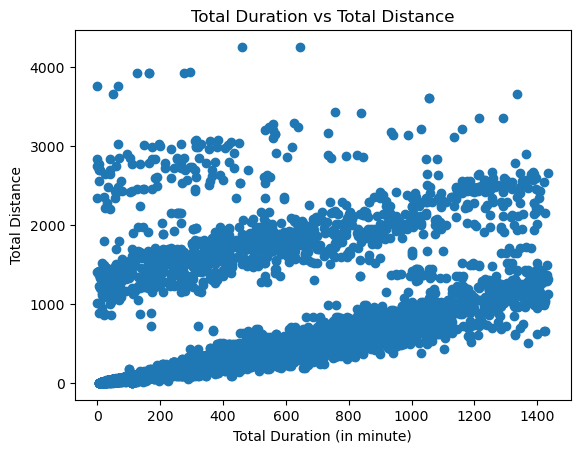

In [34]:
plt.scatter(df['Total_Duration_Minute'], df['Total_Distance'])
plt.title('Total Duration vs Total Distance')
plt.xlabel('Total Duration (in minute)')
plt.ylabel('Total Distance')

In [35]:
df = df[df['Total_Distance']<3000]

In [36]:
df

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,480.0,2694,14
4,401,750.0,1618,12
...,...,...,...,...
11108,99904,50.0,34,12
11109,99905,43.0,31,11
11110,99906,50.0,34,12
11111,99907,52.0,34,12


## ****Task 3.2: Visualize the impact of number of stops on journey duration****

Text(0.5, 0, 'Total Duration (in minute)')

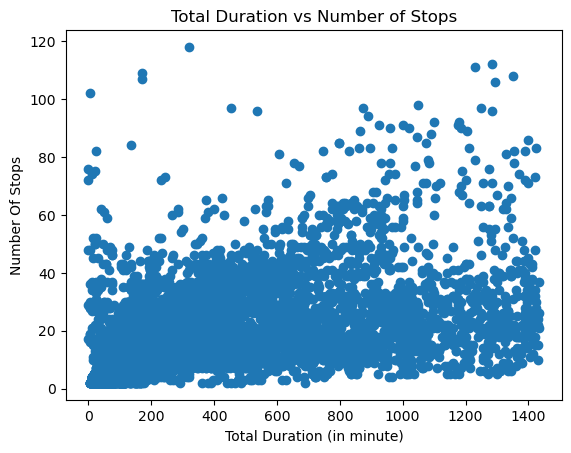

In [37]:
plt.scatter(df['Total_Duration_Minute'], df['Number_Of_Stops'])
plt.title('Total Duration vs Number of Stops')
plt.ylabel('Number Of Stops')
plt.xlabel('Total Duration (in minute)')

In [38]:
df = df[df['Number_Of_Stops']<100]

In [39]:
df

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,480.0,2694,14
4,401,750.0,1618,12
...,...,...,...,...
11108,99904,50.0,34,12
11109,99905,43.0,31,11
11110,99906,50.0,34,12
11111,99907,52.0,34,12


## ****Task 3.3: Create correlation visuals between input features and journey duration****


In [40]:
correlation = df.corr()[['Total_Duration_Minute']].sort_values(by='Total_Duration_Minute', ascending=False)
correlation = correlation.drop(index='Total_Duration_Minute')

In [41]:
import seaborn as sns

Text(0.5, 1.0, 'Correlation Between Features')

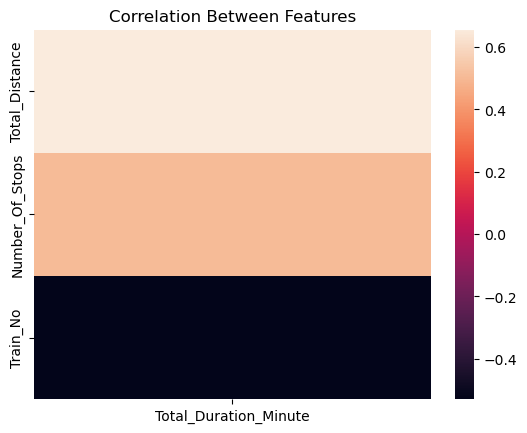

In [42]:
sns.heatmap(correlation)
plt.title("Correlation Between Features")

### ****Since Total Duration has no correlation with Train No, let's remove the column completely****

In [43]:
df = df.drop('Train_No', axis=1)

In [44]:
df

,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,105.0,78,4
1,115.0,83,4
2,1325.0,978,22
3,480.0,2694,14
4,750.0,1618,12
...,...,...,...
11108,50.0,34,12
11109,43.0,31,11
11110,50.0,34,12
11111,52.0,34,12


## ****Task 3.4: Build a pivot table summarizing number of stops for each train****

In [45]:
df['Number_Of_Stops'].unique()

array([ 4, 22, 14, 12,  5,  9,  3,  2, 18, 10, 11, 24, 26, 17, 13,  7, 16,
       29, 21,  6, 15, 20, 53, 27, 19, 85,  8, 36, 34, 28, 40, 37, 39, 30,
       33, 49, 47, 38, 46, 31, 52, 35, 62, 60, 23, 90, 91, 41, 43, 67, 65,
       25, 32, 45, 50, 56, 54, 48, 42, 44, 63, 64, 51, 57, 77, 78, 66, 89,
       82, 84, 96, 97, 74, 71, 61, 58, 73, 59, 55, 81, 72, 83, 76, 75, 98,
       92, 94, 68, 70, 86, 79, 88, 87])

In [46]:
Pivot_Table = pd.pivot_table(
    df,
    values=['Total_Duration_Minute', 'Total_Distance'], 
    index='Number_Of_Stops',                            
    aggfunc='max')

In [47]:
Pivot_Table

,Total_Distance,Total_Duration_Minute
Number_Of_Stops,,
2,1301,690.0
3,1429,630.0
4,1376,965.0
5,1449,1300.0
6,2351,1345.0
...,...,...
92,1678,1180.0
94,1759,890.0
96,2535,1285.0


In [48]:
Pivot_Table.describe()

,Total_Distance,Total_Duration_Minute
count,93.000000,93.000000
mean,2243.236559,1271.774194
std,589.197564,209.872691
min,618.000000,135.000000
25%,1945.000000,1205.000000
50%,2353.000000,1345.000000
75%,2729.000000,1405.000000
max,2993.000000,1435.000000


In [49]:
Pivot_Table = pd.pivot_table(
    df,
    values=['Total_Duration_Minute', 'Total_Distance'], 
    index='Number_Of_Stops',                            
    aggfunc='mean')

In [50]:
Pivot_Table

,Total_Distance,Total_Duration_Minute
Number_Of_Stops,,
2,33.341873,52.306645
3,47.201571,66.664921
4,77.919118,85.507353
5,147.828000,146.628000
6,163.204819,161.903614
...,...,...
92,1140.000000,1140.000000
94,1759.000000,890.000000
96,2256.500000,910.000000


In [51]:
Pivot_Table.describe()

,Total_Distance,Total_Duration_Minute
count,93.000000,93.000000
mean,868.270544,635.976096
std,489.328731,314.431642
min,33.341873,52.306645
25%,514.164384,375.836364
50%,871.000000,641.750000
75%,1133.076923,869.000000
max,2256.500000,1400.000000


In [52]:
df.isnull().sum()

Total_Duration_Minute    0
Total_Distance           0
Number_Of_Stops          0
dtype: int64

In [53]:
df = df.dropna()

In [54]:
df.isnull().sum()

Total_Duration_Minute    0
Total_Distance           0
Number_Of_Stops          0
dtype: int64

# ****Level 4: Model Training and Evaluation****

## ****Task 4.1: Split the dataset into training and testing sets****

In [55]:
df

,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,105.0,78,4
1,115.0,83,4
2,1325.0,978,22
3,480.0,2694,14
4,750.0,1618,12
...,...,...,...
11108,50.0,34,12
11109,43.0,31,11
11110,50.0,34,12
11111,52.0,34,12


In [56]:
X = df.drop('Total_Duration_Minute', axis=1)
X

,Total_Distance,Number_Of_Stops
0,78,4
1,83,4
2,978,22
3,2694,14
4,1618,12
...,...,...
11108,34,12
11109,31,11
11110,34,12
11111,34,12


In [57]:
y = df['Total_Duration_Minute']
y

0         105.0
1         115.0
2        1325.0
3         480.0
4         750.0
          ...  
11108      50.0
11109      43.0
11110      50.0
11111      52.0
11112      50.0
Name: Total_Duration_Minute, Length: 11058, dtype: float64

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
X_train

,Total_Distance,Number_Of_Stops
6746,139,19
4114,39,17
8050,25,7
8837,123,20
7328,377,37
...,...,...
5783,13,2
5240,31,14
5439,57,14
863,1025,14


In [61]:
X_test

,Total_Distance,Number_Of_Stops
9596,10,2
7587,535,59
10656,28,2
3041,157,6
5551,37,22
...,...,...
7295,92,11
2419,1663,39
5166,82,21
10718,10,2


In [62]:
y_train

6746     305.0
4114      64.0
8050      45.0
8837     205.0
7328     550.0
         ...  
5783      35.0
5240      70.0
5439     135.0
863     1110.0
7321     275.0
Name: Total_Duration_Minute, Length: 8846, dtype: float64

In [63]:
y_test

9596      15.0
7587     895.0
10656     47.0
3041     260.0
5551      83.0
         ...  
7295     165.0
2419     550.0
5166     135.0
10718     20.0
481      520.0
Name: Total_Duration_Minute, Length: 2212, dtype: float64

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

Columns_To_Scale = ['Total_Distance', 'Number_Of_Stops']

ct = ColumnTransformer([
    ('scaler', StandardScaler(), Columns_To_Scale)
], remainder='passthrough')

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train = pd.DataFrame(X_train, columns=ct.get_feature_names_out())
X_test = pd.DataFrame(X_test, columns=ct.get_feature_names_out())

In [65]:
X_train

,scaler__Total_Distance,scaler__Number_Of_Stops
0,-0.349284,0.198899
1,-0.525871,0.039722
2,-0.550593,-0.756162
3,-0.377538,0.278487
4,0.070992,1.631490
...,...,...
8841,-0.571783,-1.154103
8842,-0.539997,-0.199043
8843,-0.494085,-0.199043
8844,1.215273,-0.199043


In [66]:
X_test

,scaler__Total_Distance,scaler__Number_Of_Stops
0,-0.577081,-1.154103
1,0.349999,3.382434
2,-0.545295,-1.154103
3,-0.317498,-0.835750
4,-0.529402,0.437664
...,...,...
2207,-0.432280,-0.437808
2208,2.341895,1.790667
2209,-0.449938,0.358076
2210,-0.577081,-1.154103


## ****Task 4.2: Train a Linear Regression model using training data****

In [67]:
from sklearn.linear_model import LinearRegression

In [68]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
train_pred_lr = model_lr.predict(X_train)
test_pred_lr = model_lr.predict(X_test)

## ****Task 4.3: Evaluate model accuracy using MAE and RMSE****

In [70]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [71]:
train_mae_lr = mean_absolute_error(y_train, train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, test_pred_lr)

In [72]:
train_rmse_lr = root_mean_squared_error(y_train, train_pred_lr)
test_rmse_lr = root_mean_squared_error(y_test, test_pred_lr)

## ****Task 4.4: Visualize actual vs predicted journey durations****

Text(0, 0.5, 'Predicted Value')

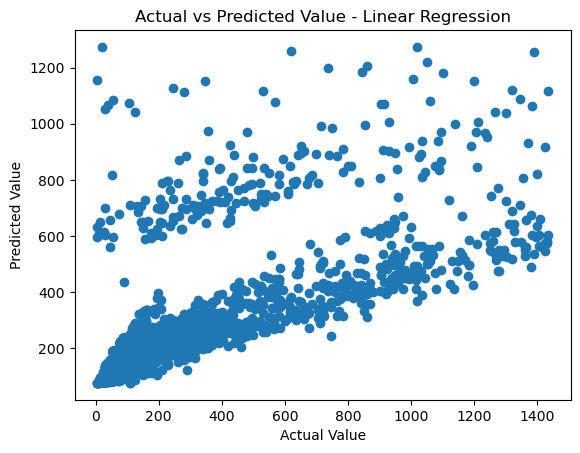

In [73]:
plt.scatter(y_test, test_pred_lr)
plt.title('Actual vs Predicted Value - Linear Regression')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

# ****Level 5: Model Comparison and User Testing****

## ****Task 5.1: Train a basic model using only one input feature****

### ****Since Total Duration have higest correlation with Number Of Stops. Therefore, let's consider the feature****

In [74]:
X_One = df.drop(['Number_Of_Stops', 'Total_Duration_Minute'], axis=1)
X_One

,Total_Distance
0,78
1,83
2,978
3,2694
4,1618
...,...
11108,34
11109,31
11110,34
11111,34


In [75]:
y_One = df['Total_Duration_Minute']
y_One

0         105.0
1         115.0
2        1325.0
3         480.0
4         750.0
          ...  
11108      50.0
11109      43.0
11110      50.0
11111      52.0
11112      50.0
Name: Total_Duration_Minute, Length: 11058, dtype: float64

In [76]:
X_One_Train, X_One_Test, y_One_Train, y_One_Test = train_test_split(X_One, y_One, test_size=0.2, random_state=42)

In [77]:
X_One_Train

,Total_Distance
6746,139
4114,39
8050,25
8837,123
7328,377
...,...
5783,13
5240,31
5439,57
863,1025


In [78]:
X_One_Test

,Total_Distance
9596,10
7587,535
10656,28
3041,157
5551,37
...,...
7295,92
2419,1663
5166,82
10718,10


In [79]:
y_One_Train

6746     305.0
4114      64.0
8050      45.0
8837     205.0
7328     550.0
         ...  
5783      35.0
5240      70.0
5439     135.0
863     1110.0
7321     275.0
Name: Total_Duration_Minute, Length: 8846, dtype: float64

In [80]:
y_One_Test

9596      15.0
7587     895.0
10656     47.0
3041     260.0
5551      83.0
         ...  
7295     165.0
2419     550.0
5166     135.0
10718     20.0
481      520.0
Name: Total_Duration_Minute, Length: 2212, dtype: float64

### ****We are going to tree based algorithms since the dataset is non-linear and in the form of tabulated structure.****

### ****We can tune the model to give better results by giving best hyperparamaters to the model found using GridSearchCV or RandomizedSearchCV. We are using GridSearchCV since it gives better results than RandomizedSearchCV even though it takes lot of computing.****

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

parameter_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='r2',
    n_jobs=-1,     
    verbose=2
)

grid_search_rf.fit(X_One_Train, y_One_Train)

grid_search_rf.best_params_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 500}

In [82]:
model_rf1 = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
model_rf1.fit(X_One_Train, y_One_Train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
train_pred_rf1 = model_rf1.predict(X_One_Train)
test_pred_rf1 = model_rf1.predict(X_One_Test)

In [84]:
train_mae_rf1 = mean_absolute_error(y_One_Train, train_pred_rf1)
test_mae_rf1 = mean_absolute_error(y_One_Test, test_pred_rf1)

In [85]:
train_rmse_rf1 = root_mean_squared_error(y_One_Train, train_pred_rf1)
test_rmse_rf1 = root_mean_squared_error(y_One_Test, test_pred_rf1)

In [86]:
train_r2_rf1 = r2_score(y_One_Train, train_pred_rf1)
test_r2_rf1 = r2_score(y_One_Test, test_pred_rf1)

In [87]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

parameter_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_One_Train, y_train)

grid_search_xgb.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

In [88]:
model_xgb1 = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)
model_xgb1.fit(X_One_Train, y_One_Train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [89]:
train_pred_xgb1 = model_xgb1.predict(X_One_Train)
test_pred_xgb1 = model_xgb1.predict(X_One_Test)

In [90]:
train_mae_xgb1 = mean_absolute_error(y_One_Train, train_pred_xgb1)
test_mae_xgb1 = mean_absolute_error(y_One_Test, test_pred_xgb1)

In [91]:
train_rmse_xgb1 = root_mean_squared_error(y_One_Train, train_pred_xgb1)
test_rmse_xgb1 = root_mean_squared_error(y_One_Test, test_pred_xgb1)

In [92]:
train_r2_xgb1 = r2_score(y_One_Train, train_pred_xgb1)
test_r2_xgb1 = r2_score(y_One_Test, test_pred_xgb1)

In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

parameter_grid= {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [10, 20, 50],
}

grid_search_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_lgb.fit(X_One_Train, y_One_Train)

grid_search_lgb.best_params_

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 1
[LightGBM] [Info] Start training from score 274.138142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

{'learning_rate': 0.05,
 'max_depth': 6,
 'min_child_samples': 20,
 'n_estimators': 100,
 'num_leaves': 31}

In [94]:
model_lgbm1 = LGBMRegressor(**grid_search_lgb.best_params_, random_state=42)
model_lgbm1.fit(X_One_Train, y_One_Train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 1
[LightGBM] [Info] Start training from score 274.138142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [95]:
train_pred_lgbm1 = model_lgbm1.predict(X_One_Train)
test_pred_lgbm1 = model_lgbm1.predict(X_One_Test)

In [96]:
train_mae_lgbm1 = mean_absolute_error(y_One_Train, train_pred_lgbm1)
test_mae_lgbm1 = mean_absolute_error(y_One_Test, test_pred_lgbm1)

In [97]:
train_rmse_lgbm1 = root_mean_squared_error(y_One_Train, train_pred_lgbm1)
test_rmse_lgbm1 = root_mean_squared_error(y_One_Test, test_pred_lgbm1)

In [98]:
train_r2_lgbm1 = r2_score(y_One_Train, train_pred_lgbm1)
test_r2_lgbm1 = r2_score(y_One_Test, test_pred_lgbm1)

In [99]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(allow_writing_files=False, random_state=42)

parameter_grid = {
    "iterations": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 10],
    "min_data_in_leaf": [10, 20, 50],
    "l2_leaf_reg": [1, 3, 5, 10],
}

grid_search_cat = GridSearchCV(
    estimator=cat,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_cat.fit(X_One_Train, y_One_Train)

grid_search_cat.best_params_

Fitting 3 folds for each of 324 candidates, totalling 972 fits
0:	learn: 307.5631985	total: 140ms	remaining: 1m 9s
1:	learn: 297.3711708	total: 142ms	remaining: 35.4s
2:	learn: 287.4667168	total: 144ms	remaining: 23.9s
3:	learn: 278.5050247	total: 146ms	remaining: 18.1s
4:	learn: 269.4563598	total: 148ms	remaining: 14.6s
5:	learn: 261.1606859	total: 150ms	remaining: 12.3s
6:	learn: 253.3967802	total: 152ms	remaining: 10.7s
7:	learn: 246.4389328	total: 154ms	remaining: 9.46s
8:	learn: 239.8967681	total: 156ms	remaining: 8.49s
9:	learn: 233.5337974	total: 158ms	remaining: 7.73s
10:	learn: 227.9043816	total: 160ms	remaining: 7.1s
11:	learn: 222.2933744	total: 162ms	remaining: 6.57s
12:	learn: 216.9224443	total: 164ms	remaining: 6.13s
13:	learn: 212.1039259	total: 166ms	remaining: 5.76s
14:	learn: 207.5620332	total: 168ms	remaining: 5.44s
15:	learn: 203.5280379	total: 171ms	remaining: 5.16s
16:	learn: 199.5593270	total: 173ms	remaining: 4.91s
17:	learn: 196.0694857	total: 175ms	remaining: 

{'depth': 6,
 'iterations': 500,
 'l2_leaf_reg': 10,
 'learning_rate': 0.05,
 'min_data_in_leaf': 10}

In [100]:
model_cat1 = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42)
model_cat1.fit(X_One_Train, y_One_Train)

0:	learn: 307.5631985	total: 2.92ms	remaining: 1.46s
1:	learn: 297.3711708	total: 5.49ms	remaining: 1.37s
2:	learn: 287.4667168	total: 7.85ms	remaining: 1.3s
3:	learn: 278.5050247	total: 10.3ms	remaining: 1.27s
4:	learn: 269.4563598	total: 12.8ms	remaining: 1.27s
5:	learn: 261.1606859	total: 15.2ms	remaining: 1.25s
6:	learn: 253.3967802	total: 17.7ms	remaining: 1.25s
7:	learn: 246.4389328	total: 20ms	remaining: 1.23s
8:	learn: 239.8967681	total: 22.2ms	remaining: 1.21s
9:	learn: 233.5337974	total: 24.7ms	remaining: 1.21s
10:	learn: 227.9043816	total: 27.5ms	remaining: 1.22s
11:	learn: 222.2933744	total: 29.8ms	remaining: 1.21s
12:	learn: 216.9224443	total: 32.2ms	remaining: 1.21s
13:	learn: 212.1039259	total: 34.6ms	remaining: 1.2s
14:	learn: 207.5620332	total: 36.9ms	remaining: 1.19s
15:	learn: 203.5280379	total: 39.9ms	remaining: 1.21s
16:	learn: 199.5593270	total: 42.3ms	remaining: 1.2s
17:	learn: 196.0694857	total: 44.6ms	remaining: 1.2s
18:	learn: 192.8103845	total: 47.1ms	remaini

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=10, learning_rate=0.05, loss_function='RMSE', min_data_in_leaf=10, random_state=42)

In [101]:
train_pred_cat1 = model_cat1.predict(X_One_Train)
test_pred_cat1 = model_cat1.predict(X_One_Test)

In [102]:
train_mae_cat1 = mean_absolute_error(y_One_Train, train_pred_cat1)
test_mae_cat1 = mean_absolute_error(y_One_Test, test_pred_cat1)

In [103]:
train_rmse_cat1 = root_mean_squared_error(y_One_Train, train_pred_cat1)
test_rmse_cat1 = root_mean_squared_error(y_One_Test, test_pred_cat1)

In [104]:
train_r2_cat1 = r2_score(y_One_Train, train_pred_cat1)
test_r2_cat1 = r2_score(y_One_Test, test_pred_cat1)

## ****Task 5.2: Train an improved model using multiple input features****

In [105]:
from sklearn.model_selection import GridSearchCV


parameter_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='r2',
    n_jobs=-1,     
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

grid_search_rf.best_params_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


{'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [106]:
model_rf2 = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
model_rf2.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
train_pred_rf2 = model_rf2.predict(X_train)
test_pred_rf2 = model_rf2.predict(X_test)

In [108]:
train_mae_rf2 = mean_absolute_error(y_train, train_pred_rf2)
test_mae_rf2 = mean_absolute_error(y_test, test_pred_rf2)

In [109]:
train_rmse_rf2 = root_mean_squared_error(y_train, train_pred_rf2)
test_rmse_rf2 = root_mean_squared_error(y_test, test_pred_rf2)

In [110]:
train_r2_rf2 = r2_score(y_train, train_pred_rf2)
test_r2_rf2 = r2_score(y_test, test_pred_rf2)

In [111]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

grid_search_xgb.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 500}

In [112]:
model_xgb2 = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)
model_xgb2.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [113]:
train_pred_xgb2 = model_xgb2.predict(X_train)
test_pred_xgb2 = model_xgb2.predict(X_test)

In [114]:
train_mae_xgb2 = mean_absolute_error(y_train, train_pred_xgb2)
test_mae_xgb2 = mean_absolute_error(y_test, test_pred_xgb2)

In [115]:
train_rmse_xgb2 = root_mean_squared_error(y_train, train_pred_xgb2)
test_rmse_xgb2 = root_mean_squared_error(y_test, test_pred_xgb2)

In [116]:
train_r2_xgb2 = r2_score(y_train, train_pred_xgb2)
test_r2_xgb2 = r2_score(y_test, test_pred_xgb2)

In [117]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

parameter_grid= {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [10, 20, 50],
}

grid_search_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_lgb.fit(X_train, y_train)

grid_search_lgb.best_params_

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 2
[LightGBM] [Info] Start training from score 274.138142


{'learning_rate': 0.05,
 'max_depth': -1,
 'min_child_samples': 10,
 'n_estimators': 100,
 'num_leaves': 31}

In [118]:
model_lgbm2 = LGBMRegressor(**grid_search_lgb.best_params_, random_state=42)
model_lgbm2.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 2
[LightGBM] [Info] Start training from score 274.138142


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [119]:
train_pred_lgbm2 = model_lgbm2.predict(X_train)
test_pred_lgbm2 = model_lgbm2.predict(X_test)

In [120]:
train_mae_lgbm2 = mean_absolute_error(y_train, train_pred_lgbm2)
test_mae_lgbm2 = mean_absolute_error(y_test, test_pred_lgbm2)

In [121]:
train_rmse_lgbm2 = root_mean_squared_error(y_train, train_pred_lgbm2)
test_rmse_lgbm2 = root_mean_squared_error(y_test, test_pred_lgbm2)

In [122]:
train_r2_lgbm2 = r2_score(y_train, train_pred_lgbm2)
test_r2_lgbm2 = r2_score(y_test, test_pred_lgbm2)

In [123]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(allow_writing_files=False, random_state=42)

parameter_grid = {
    "iterations": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 10],
    "min_data_in_leaf": [10, 20, 50],
    "l2_leaf_reg": [1, 3, 5, 10],
}

grid_search_cat = GridSearchCV(
    estimator=cat,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_cat.fit(X_train, y_train)

grid_search_cat.best_params_

Fitting 3 folds for each of 324 candidates, totalling 972 fits


0:	learn: 296.1622788	total: 22.7ms	remaining: 2.25s
1:	learn: 275.8059932	total: 44.9ms	remaining: 2.2s
2:	learn: 258.5123436	total: 69ms	remaining: 2.23s
3:	learn: 242.0683014	total: 91.6ms	remaining: 2.2s
4:	learn: 227.8086125	total: 114ms	remaining: 2.16s
5:	learn: 214.4636664	total: 138ms	remaining: 2.15s
6:	learn: 203.3107335	total: 158ms	remaining: 2.1s
7:	learn: 192.9728447	total: 181ms	remaining: 2.08s
8:	learn: 184.3781356	total: 202ms	remaining: 2.05s
9:	learn: 176.0185007	total: 225ms	remaining: 2.02s
10:	learn: 168.8089713	total: 247ms	remaining: 2s
11:	learn: 162.7642898	total: 271ms	remaining: 1.99s
12:	learn: 157.1379592	total: 294ms	remaining: 1.97s
13:	learn: 152.3281003	total: 318ms	remaining: 1.95s
14:	learn: 147.6255215	total: 342ms	remaining: 1.94s
15:	learn: 143.7374746	total: 365ms	remaining: 1.92s
16:	learn: 140.9857157	total: 387ms	remaining: 1.89s
17:	learn: 137.9050734	total: 409ms	remaining: 1.86s
18:	learn: 135.7928923	total: 430ms	remaining: 1.83s
19:	lea

{'depth': 10,
 'iterations': 100,
 'l2_leaf_reg': 1,
 'learning_rate': 0.1,
 'min_data_in_leaf': 10}

In [124]:
model_cat2 = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42)
model_cat2.fit(X_train, y_train)

0:	learn: 296.1622788	total: 31.8ms	remaining: 3.15s
1:	learn: 275.8059932	total: 59.1ms	remaining: 2.9s
2:	learn: 258.5123436	total: 84.4ms	remaining: 2.73s
3:	learn: 242.0683014	total: 114ms	remaining: 2.73s
4:	learn: 227.8086125	total: 142ms	remaining: 2.71s
5:	learn: 214.4636664	total: 169ms	remaining: 2.65s
6:	learn: 203.3107335	total: 195ms	remaining: 2.6s
7:	learn: 192.9728447	total: 224ms	remaining: 2.58s
8:	learn: 184.3781356	total: 252ms	remaining: 2.54s
9:	learn: 176.0185007	total: 277ms	remaining: 2.49s
10:	learn: 168.8089713	total: 306ms	remaining: 2.47s
11:	learn: 162.7642898	total: 332ms	remaining: 2.44s
12:	learn: 157.1379592	total: 357ms	remaining: 2.39s
13:	learn: 152.3281003	total: 384ms	remaining: 2.36s
14:	learn: 147.6255215	total: 410ms	remaining: 2.32s
15:	learn: 143.7374746	total: 439ms	remaining: 2.3s
16:	learn: 140.9857157	total: 463ms	remaining: 2.26s
17:	learn: 137.9050734	total: 489ms	remaining: 2.23s
18:	learn: 135.7928923	total: 517ms	remaining: 2.21s
19:

CatBoostRegressor(depth=10, iterations=100, l2_leaf_reg=1, learning_rate=0.1, loss_function='RMSE', min_data_in_leaf=10, random_state=42)

In [125]:
train_pred_cat2 = model_cat2.predict(X_train)
test_pred_cat2 = model_cat2.predict(X_test)

In [126]:
train_mae_cat2 = mean_absolute_error(y_train, train_pred_cat2)
test_mae_cat2 = mean_absolute_error(y_test, test_pred_cat2)

In [127]:
train_rmse_cat2 = root_mean_squared_error(y_train, train_pred_cat2)
test_rmse_cat2 = root_mean_squared_error(y_test, test_pred_cat2)

In [128]:
train_r2_cat2 = r2_score(y_train, train_pred_cat2)
test_r2_cat2 = r2_score(y_test, test_pred_cat2)

## ****Task 5.3: Compare models using error metrics and visual plots****


In [129]:
train_mae_lr, test_mae_lr, train_rmse_lr,  test_rmse_lr

(146.89071184608048, 148.80084147827597, 229.1736224782141, 230.27462867312735)

In [130]:
train_mae_rf1, test_mae_rf1, train_rmse_rf1, test_rmse_rf1, train_r2_rf1, test_r2_rf1

(55.84145691948763,
 67.3044290161959,
 120.75814855385147,
 157.33021414979643,
 0.856669056347233,
 0.7640971935691213)

In [131]:
train_mae_rf2, test_mae_rf2, train_rmse_rf2, test_rmse_rf2, train_r2_rf2, test_r2_rf2

(32.8040398319092,
 46.46715528649318,
 79.66234445419778,
 131.1495680833352,
 0.9376246155461881,
 0.8360759900882669)

In [132]:
train_mae_xgb1, test_mae_xgb1, train_rmse_xgb1, test_rmse_xgb1, train_r2_xgb1, test_r2_xgb1

(67.73140854051742,
 70.64360653944516,
 147.19932178434885,
 156.5551944022051,
 0.7870298746786236,
 0.7664156168850296)

In [153]:
train_mae_xgb2, test_mae_xgb2, train_rmse_xgb2, test_rmse_xgb2, train_r2_xgb2, test_r2_xgb2

(40.82279177486102,
 50.73783948322317,
 98.18336057679139,
 135.08781624739692,
 0.9052492068377078,
 0.8260833336268617)

In [134]:
train_mae_lgbm1, test_mae_lgbm1, train_rmse_lgbm1, test_rmse_lgbm1, train_r2_lgbm1, test_r2_lgbm1

(66.42012211738341,
 69.85553335472706,
 144.6861065070651,
 154.92972136382463,
 0.7942401055965498,
 0.7712409314464674)

In [135]:
train_mae_lgbm2, test_mae_lgbm2, train_rmse_lgbm2, test_rmse_lgbm2, train_r2_lgbm2, test_r2_lgbm2

(43.957741115580696,
 52.366346973613645,
 98.61535349009579,
 135.28824337721232,
 0.9044135923767671,
 0.8255668773243205)

In [136]:
train_mae_cat1, test_mae_cat1, train_rmse_cat1, test_rmse_cat1, train_r2_cat1, test_r2_cat1

(67.07549074421935,
 69.84414945701845,
 145.65838188551686,
 155.6251269951005,
 0.7914654445148843,
 0.7691827419528892)

In [137]:
train_mae_cat2, test_mae_cat2, train_rmse_cat2, test_rmse_cat2, train_r2_cat2, test_r2_cat2

(45.91033642901189,
 52.33435776562133,
 100.65205133209456,
 129.49450731875913,
 0.9004245381837167,
 0.8401872093629229)

Text(0, 0.5, 'Predicted Value')

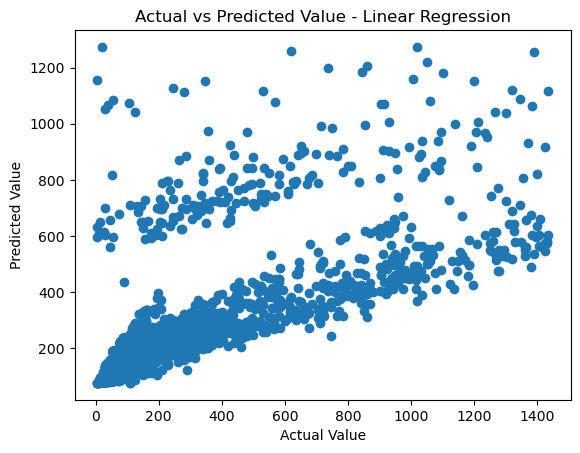

In [138]:
plt.scatter(y_test, test_pred_lr)
plt.title('Actual vs Predicted Value - Linear Regression')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

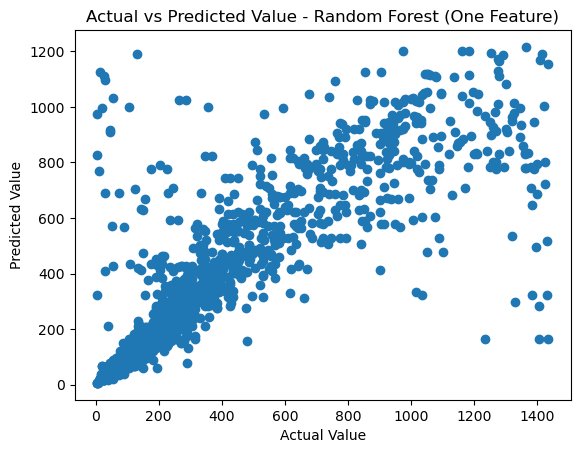

In [139]:
plt.scatter(y_test, test_pred_rf1)
plt.title('Actual vs Predicted Value - Random Forest (One Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

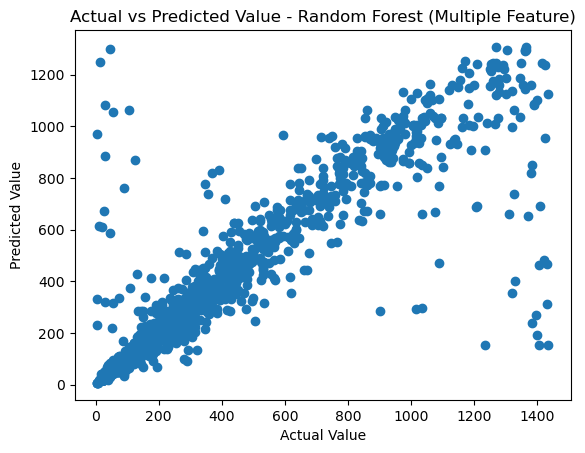

In [140]:
plt.scatter(y_test, test_pred_rf2)
plt.title('Actual vs Predicted Value - Random Forest (Multiple Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

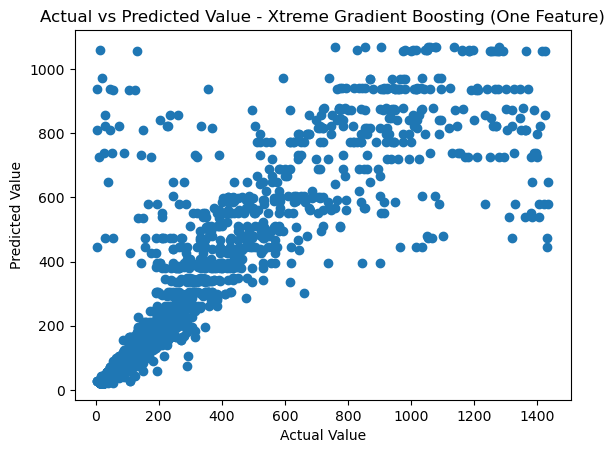

In [141]:
plt.scatter(y_test, test_pred_xgb1)
plt.title('Actual vs Predicted Value - Xtreme Gradient Boosting (One Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

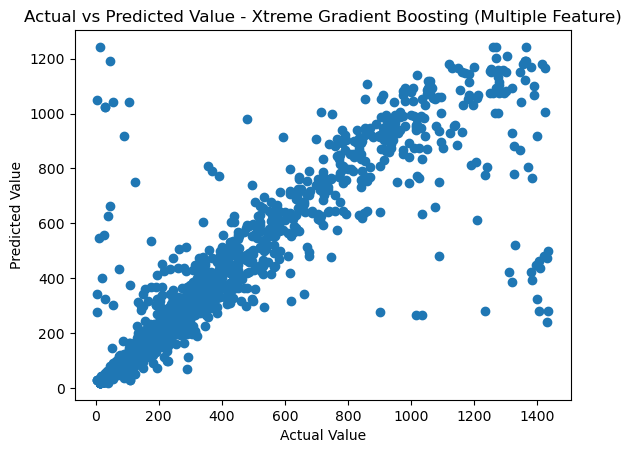

In [142]:
plt.scatter(y_test, test_pred_xgb2)
plt.title('Actual vs Predicted Value - Xtreme Gradient Boosting (Multiple Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

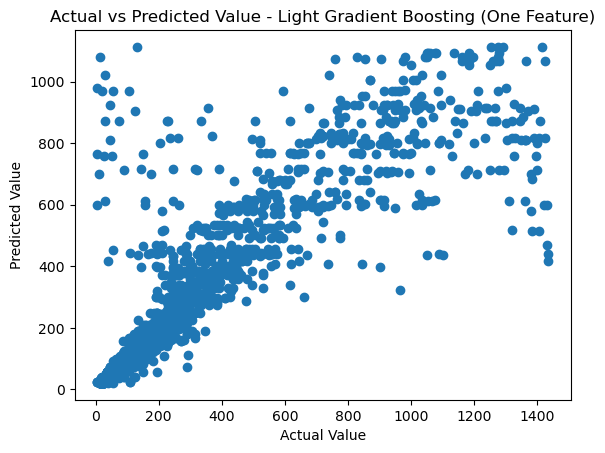

In [143]:
plt.scatter(y_test, test_pred_lgbm1)
plt.title('Actual vs Predicted Value - Light Gradient Boosting (One Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

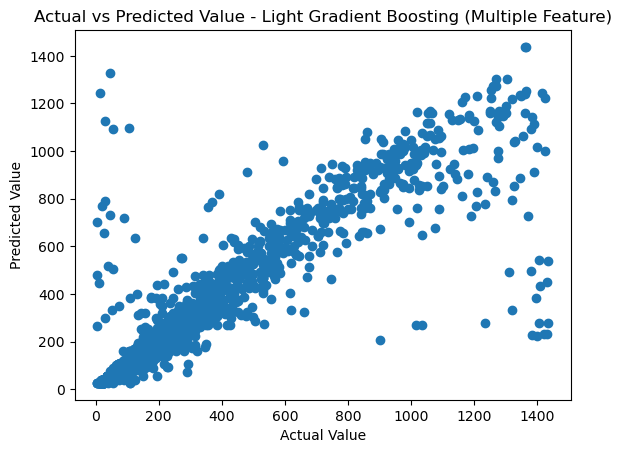

In [144]:
plt.scatter(y_test, test_pred_lgbm2)
plt.title('Actual vs Predicted Value - Light Gradient Boosting (Multiple Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

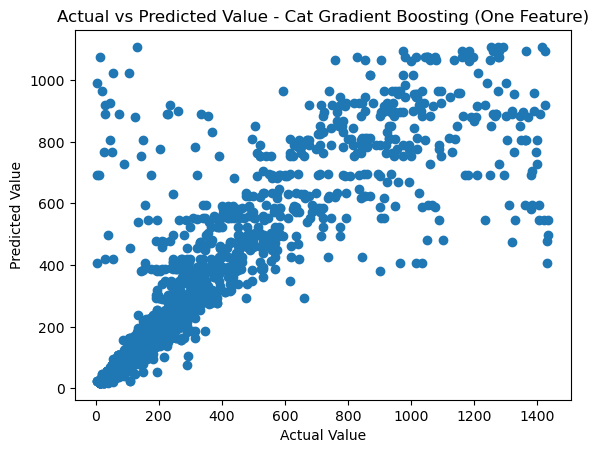

In [145]:
plt.scatter(y_test, test_pred_cat1)
plt.title('Actual vs Predicted Value - Cat Gradient Boosting (One Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

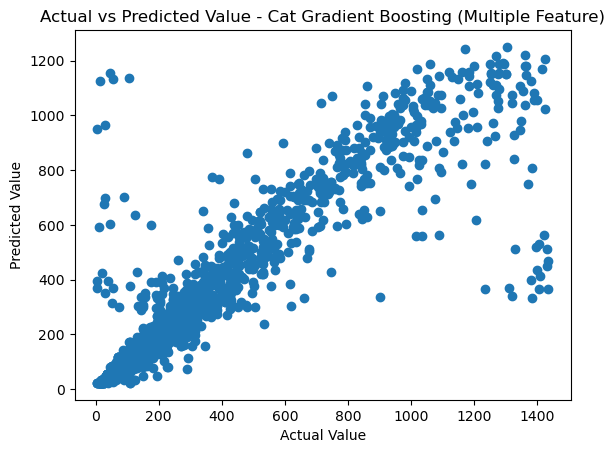

In [146]:
plt.scatter(y_test, test_pred_cat2)
plt.title('Actual vs Predicted Value - Cat Gradient Boosting (Multiple Feature)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

## ****Task 5.4: Select the model with better performance based on evaluation****

### ****Random Forest Regressor (Multiple Features) gives better results since the model understands the dataset rather than memorising like Xtreme Gradient Boosting Regressor (Multiple Features), Light Gradient Boosting (Multiple Features), Categorical Boosting(Multiple Feature).****

In [154]:
model = model_cat2

In [155]:
import joblib

In [156]:
joblib.dump(model, 'Machine Learning Model.pkl')

['Machine Learning Model.pkl']